# Genetic Programming for Image Feature Extraction

This notebook provides an implementation workflow for evaluating the GP-FR feature-learning baseline on the FEI facial image dataset.

It contains:

1. Dataset validation and preprocessing  
2. A 5-class initial validation experiment  
3. A 10-class main experiment  
4. A raw-pixel SVM baseline  
5. A concise comparison of the final results  


## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
from skimage import color, io, transform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC

# Project and dataset paths
PROJECT_ROOT = Path.cwd()
FEI_DIR = Path.home() / "Downloads" / "originalimages_part1"
GPFR_DIR = Path.home() / "Downloads" / "baselines original" / "gp_fr"

# Dataset settings
IMAGE_SIZE = (64, 64)
TEST_SIZE = 0.30
RANDOM_STATE = 42

# Experiment settings
SMOKE_CLASSES = 5
SMOKE_POPULATION = 10
SMOKE_GENERATIONS = 2

MAIN_CLASSES = 10
MAIN_POPULATION = 20
MAIN_GENERATIONS = 5
EXPERIMENT_SEED = 0

print("Project root:", PROJECT_ROOT)
print("FEI directory:", FEI_DIR)
print("GP-FR directory:", GPFR_DIR)

Project root: c:\Users\james\Downloads
FEI directory: C:\Users\james\Downloads\originalimages_part1
GP-FR directory: C:\Users\james\Downloads\baselines original\gp_fr


## 2. Validate the dataset and GP-FR package


In [2]:
# Validate the FEI dataset
if not FEI_DIR.exists():
    raise FileNotFoundError(f"FEI dataset folder not found: {FEI_DIR}")

image_paths = sorted(
    FEI_DIR.glob("*.jpg"),
    key=lambda path: tuple(map(int, path.stem.split("-"))),
)

if len(image_paths) != 700:
    raise ValueError(f"Expected 700 FEI images, but found {len(image_paths)}")

# Validate the GP-FR package
required_gpfr_files = [
    "__init__.py",
    "gp_fr_main.py",
    "gp_fr_functions.py",
    "gp_fr_types.py",
    "gp_restrict.py",
    "sift_features.py",
]

missing_files = [
    filename
    for filename in required_gpfr_files
    if not (GPFR_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing GP-FR files: " + ", ".join(missing_files)
    )

print(f"Dataset validation passed: {len(image_paths)} images found")
print("First five files:", [path.name for path in image_paths[:5]])
print("Last five files:", [path.name for path in image_paths[-5:]])
print("GP-FR package validation passed")

Dataset validation passed: 700 images found
First five files: ['1-01.jpg', '1-02.jpg', '1-03.jpg', '1-04.jpg', '1-05.jpg']
Last five files: ['50-10.jpg', '50-11.jpg', '50-12.jpg', '50-13.jpg', '50-14.jpg']
GP-FR package validation passed


## 3. Load and preprocess the FEI images

Each image is converted to grayscale, resized to 64 × 64 pixels, and stored as a floating-point NumPy array.

In [3]:
images = []
labels = []

for path in image_paths:
    image = io.imread(path)

    if image.ndim == 3:
        image = color.rgb2gray(image)

    image = transform.resize(
        image,
        IMAGE_SIZE,
        anti_aliasing=True,
    )

    images.append(image.astype(np.float32))

    # Example: "17-06.jpg" becomes class label 16
    person_id = int(path.stem.split("-")[0]) - 1
    labels.append(person_id)

X = np.stack(images)
y = np.asarray(labels, dtype=np.int64)

print("Image array shape:", X.shape)
print("Label array shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print(f"Pixel range: {X.min():.3f} to {X.max():.3f}")

Image array shape: (700, 64, 64)
Label array shape: (700,)
Number of classes: 50
Pixel range: 0.003 to 0.905


## 4. Create the training and test sets

A stratified 70/30 split preserves the representation of all identities in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (490, 64, 64)
Training labels: (490,)
Test images: (210, 64, 64)
Test labels: (210,)


## 5. Visualise example FEI images


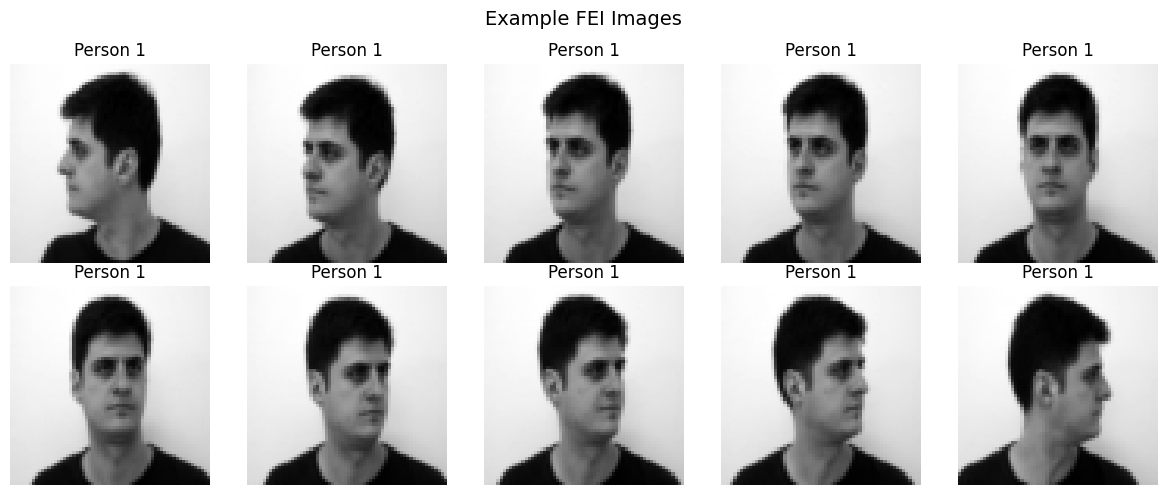

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image, label in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Person {label + 1}")
    ax.axis("off")

plt.suptitle("Example FEI Images", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Import the GP-FR implementation


In [6]:
import sys
from pathlib import Path

GPFR_PARENT = Path.home() / "Downloads" / "baselines original"

if str(GPFR_PARENT) not in sys.path:
    sys.path.insert(0, str(GPFR_PARENT))

import gp_fr.gp_fr_main as gpfr

print("GP-FR imported successfully")

GP-FR imported successfully


## 7. Initial validation experiment — 5 classes

This reduced experiment confirms that the complete pipeline works before the larger experiment is run.

- Classes: 5  
- Population: 10  
- Generations: 2

In [7]:
smoke_train_mask = y_train < SMOKE_CLASSES
smoke_test_mask = y_test < SMOKE_CLASSES

X_train_smoke = X_train[smoke_train_mask]
y_train_smoke = y_train[smoke_train_mask]
X_test_smoke = X_test[smoke_test_mask]
y_test_smoke = y_test[smoke_test_mask]

print("Smoke-test training set:", X_train_smoke.shape)
print("Smoke-test test set:", X_test_smoke.shape)
print("Smoke-test classes:", np.unique(y_train_smoke))

gpfr.POPULATION = SMOKE_POPULATION
gpfr.GENERATION = SMOKE_GENERATIONS

smoke_result = gpfr.run_gp_fr(
    X_train_smoke,
    y_train_smoke,
    X_test_smoke,
    y_test_smoke,
    seed=EXPERIMENT_SEED,
    verbose=True,
)

Smoke-test training set: (50, 64, 64)
Smoke-test test set: (20, 64, 64)
Smoke-test classes: [0 1 2 3 4]
gen	nevals	avg 	max
0  	10    	86.2	98 
1  	9     	97.6	100
2  	9     	99.2	100

=== GP-FR Results (seed=0) ===
Training time: 4.8s
Best train fitness: 100.00%
Test accuracy: 90.00% (classifier: SVM)
Feature dim: 146
Program: FC2(SIFT_R(GauD_R(Max_R(Gau_R(Sobel_R(RegionR(Image, 12, 7, 52, 57)), 3)), 1, 1, 0)), DIF_R(LoG2_R(SobelY_R(RegionR(Image, 6, 57, 30, 22)))))


### 5-class validation summary

In [8]:
print("=== 5-Class Initial Validation ===")
print(f"Training fitness: {smoke_result['train_fitness']:.2f}%")
print(f"Test accuracy: {smoke_result['test_acc']:.2f}%")
print(f"Classifier: {smoke_result['classifier']}")
print(f"Feature dimension: {smoke_result['feature_dim']}")
print(f"Training time: {smoke_result['train_time']:.2f} seconds")
print("Evolved program:")
print(smoke_result["program"])

=== 5-Class Initial Validation ===
Training fitness: 100.00%
Test accuracy: 90.00%
Classifier: SVM
Feature dimension: 146
Training time: 4.80 seconds
Evolved program:
FC2(SIFT_R(GauD_R(Max_R(Gau_R(Sobel_R(RegionR(Image, 12, 7, 52, 57)), 3)), 1, 1, 0)), DIF_R(LoG2_R(SobelY_R(RegionR(Image, 6, 57, 30, 22)))))


## 8. Main GP-FR experiment — 10 classes

This is the principal experiment used for the results presentation.

- Classes: 10  
- Population: 20  
- Generations: 5

In [9]:
main_train_mask = y_train < MAIN_CLASSES
main_test_mask = y_test < MAIN_CLASSES

X_train_main = X_train[main_train_mask]
y_train_main = y_train[main_train_mask]
X_test_main = X_test[main_test_mask]
y_test_main = y_test[main_test_mask]

print("Main training set:", X_train_main.shape)
print("Main test set:", X_test_main.shape)
print("Main classes:", np.unique(y_train_main))

gpfr.POPULATION = MAIN_POPULATION
gpfr.GENERATION = MAIN_GENERATIONS

results = []

for seed in range(10):
    print("\n" + "=" * 60)
    print(f"Running main GP-FR experiment with seed {seed}")
    print("=" * 60)

    result = gpfr.run_gp_fr(
        X_train_main,
        y_train_main,
        X_test_main,
        y_test_main,
        seed=seed,
        verbose=True,
    )

    result["seed"] = seed
    results.append(result)

print("\nAll 10 GP-FR runs completed.")


Main training set: (99, 64, 64)
Main test set: (41, 64, 64)
Main classes: [0 1 2 3 4 5 6 7 8 9]

Running main GP-FR experiment with seed 0
gen	nevals	avg    	max
0  	20    	85.9455	100
1  	19    	99.5275	100
2  	19    	98.9245	100
3  	19    	99.6865	100
4  	19    	99.7375	100
5  	19    	99.7375	100

=== GP-FR Results (seed=0) ===
Training time: 93.3s
Best train fitness: 100.00%
Test accuracy: 95.12% (classifier: SVM)
Feature dim: 703
Program: FC4(HOG(Image), uLBP_R(LoG1_R(GauD_R(Gau_R(RegionS(Image, 51, 12, 53), 1), 3, 1, 0))), uLBP_R(SobelY_R(RegionR(Image, 12, 38, 55, 17))), HOG_R(Mean_R(LoG1_R(RegionS(Lap(Image), 17, 54, 55)))))

Running main GP-FR experiment with seed 1
gen	nevals	avg   	max
0  	20    	93.802	99 
1  	19    	97.996	100
2  	19    	98.0555	100
3  	19    	99.079 	100
4  	19    	99.79  	100
5  	19    	99.845 	100

=== GP-FR Results (seed=1) ===
Training time: 173.4s
Best train fitness: 100.00%
Test accuracy: 97.56% (classifier: SVM)
Feature dim: 1275
Program: FC4(HOG(So

## 9. Raw-pixel SVM baseline

This baseline tests how well a Linear SVM performs when given the resized raw pixels directly, without GP feature extraction.

In [10]:
raw_train = X_train_main.reshape(len(X_train_main), -1)
raw_test = X_test_main.reshape(len(X_test_main), -1)

raw_scaler = MinMaxScaler()
raw_train_scaled = raw_scaler.fit_transform(raw_train)
raw_test_scaled = raw_scaler.transform(raw_test)

raw_classifier = LinearSVC(max_iter=5000)
raw_classifier.fit(raw_train_scaled, y_train_main)

raw_accuracy = 100 * raw_classifier.score(
    raw_test_scaled,
    y_test_main,
)

gp_accuracies = [result["test_acc"] for result in results]
mean_gp_accuracy = np.mean(gp_accuracies)

print(f"Raw-pixel SVM accuracy: {raw_accuracy:.2f}%")
print(f"Mean GP feature accuracy over 10 seeds: {mean_gp_accuracy:.2f}%")


Raw-pixel SVM accuracy: 87.80%
Mean GP feature accuracy over 10 seeds: 96.83%


## 10. Final experiment summary

In [11]:
import csv

accuracies = np.array([result["test_acc"] for result in results], dtype=float)
fitnesses = np.array([result["train_fitness"] for result in results], dtype=float)
times = np.array([result["train_time"] for result in results], dtype=float)
features = np.array([result["feature_dim"] for result in results], dtype=float)

print("=== Individual GP-FR Runs ===")
for result in results:
    print(
        f"Seed {result['seed']}: "
        f"accuracy={result['test_acc']:.2f}% | "
        f"fitness={result['train_fitness']:.2f}% | "
        f"features={result['feature_dim']} | "
        f"time={result['train_time']:.2f}s | "
        f"classifier={result['classifier']}"
    )

print("\n=== 10-Run Final Summary ===")
print(f"Training images: {len(X_train_main)}")
print(f"Test images: {len(X_test_main)}")
print(f"Number of classes: {MAIN_CLASSES}")
print(f"Population: {MAIN_POPULATION}")
print(f"Generations: {MAIN_GENERATIONS}")
print(f"Mean training fitness: {np.mean(fitnesses):.2f}%")
print(f"Mean GP test accuracy: {np.mean(accuracies):.2f}%")
print(f"GP accuracy standard deviation: {np.std(accuracies, ddof=1):.2f}")
print(f"Minimum GP accuracy: {np.min(accuracies):.2f}%")
print(f"Maximum GP accuracy: {np.max(accuracies):.2f}%")
print(f"Raw-pixel SVM accuracy: {raw_accuracy:.2f}%")
print(f"Mean feature dimension: {np.mean(features):.1f}")
print(f"Mean training time: {np.mean(times):.2f} seconds")

csv_path = PROJECT_ROOT / "gp_fr_10_seed_results.csv"
with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow([
        "seed",
        "test_accuracy_percent",
        "training_fitness_percent",
        "feature_dimension",
        "training_time_seconds",
        "classifier",
        "program",
    ])
    for result in results:
        writer.writerow([
            result["seed"],
            result["test_acc"],
            result["train_fitness"],
            result["feature_dim"],
            result["train_time"],
            result["classifier"],
            result["program"],
        ])

print(f"\nResults saved to: {csv_path}")


=== Individual GP-FR Runs ===
Seed 0: accuracy=95.12% | fitness=100.00% | features=703 | time=93.28s | classifier=SVM
Seed 1: accuracy=97.56% | fitness=100.00% | features=1275 | time=173.35s | classifier=SVM
Seed 2: accuracy=97.56% | fitness=100.00% | features=722 | time=262.35s | classifier=LR
Seed 3: accuracy=97.56% | fitness=100.00% | features=187 | time=132.72s | classifier=RF
Seed 4: accuracy=97.56% | fitness=100.00% | features=753 | time=133.06s | classifier=SVM
Seed 5: accuracy=95.12% | fitness=100.00% | features=702 | time=250.19s | classifier=SVM
Seed 6: accuracy=97.56% | fitness=100.00% | features=694 | time=189.57s | classifier=SVM
Seed 7: accuracy=97.56% | fitness=100.00% | features=827 | time=295.77s | classifier=SVM
Seed 8: accuracy=97.56% | fitness=100.00% | features=1170 | time=199.95s | classifier=SVM
Seed 9: accuracy=95.12% | fitness=100.00% | features=717 | time=183.78s | classifier=RF

=== 10-Run Final Summary ===
Training images: 99
Test images: 41
Number of classe

## 11. Accuracy comparison

This chart provides a simple visual comparison for the results slides.

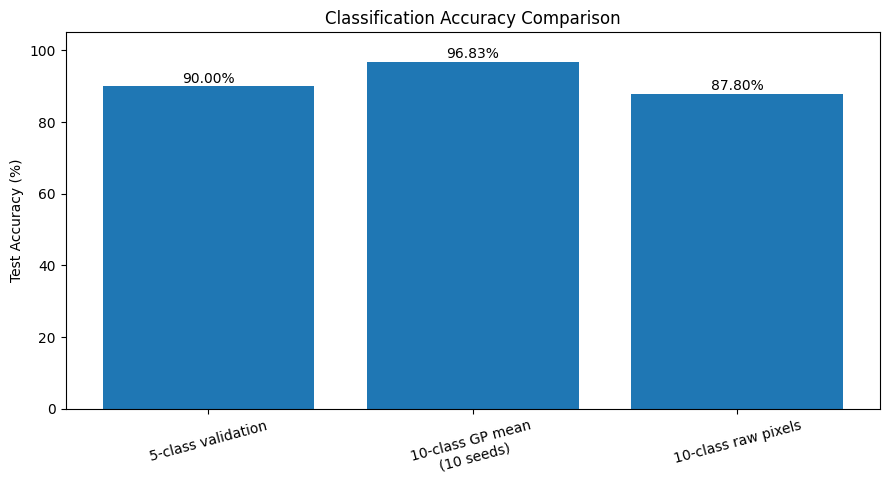

In [12]:
methods = [
    "5-class validation",
    "10-class GP mean\n(10 seeds)",
    "10-class raw pixels",
]

comparison_accuracies = [
    smoke_result["test_acc"],
    np.mean(accuracies),
    raw_accuracy,
]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, comparison_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Classification Accuracy Comparison")
plt.ylim(0, 105)
plt.xticks(rotation=15)

for bar, accuracy in zip(bars, comparison_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
    )

plt.tight_layout()
plt.show()


Loading results from: C:\Users\james\Downloads\gp_fr_10_seed_results.csv

Best result
------------------------------------------------------------
Seed/run: 1
Accuracy: 97.5600
Programme:
FC4(HOG(SobelX(SobelX(SobelY(Max(Image))))), uLBP(LoG1(SobelX(LoG1(Max(Image))))), HOG(Sobel(Med(Image))), Hist_R(Med_R(Med_R(Mean_R(RegionR(LoG2(Image), 32, 19, 44, 54))))))

Saved files
------------------------------------------------------------
SVG: C:\Users\james\Downloads\figures\best_original_gp_tree.svg
PNG: C:\Users\james\Downloads\figures\best_original_gp_tree.png
PDF: C:\Users\james\Downloads\figures\best_original_gp_tree.pdf


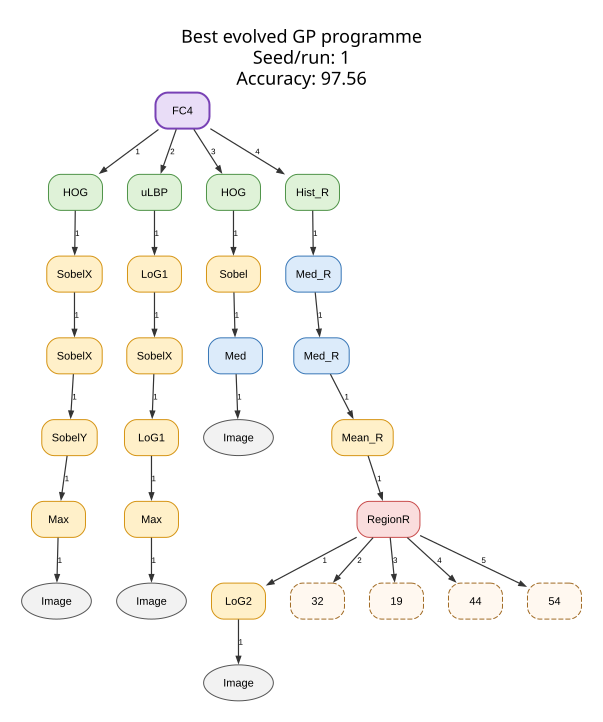

In [13]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"
from pathlib import Path
import ast
import re

import pandas as pd
from graphviz import Digraph
from IPython.display import display, Image, SVG


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

# Change this only when your results DataFrame has a different name.
POSSIBLE_DATAFRAME_NAMES = [
    "results_df",
    "results",
    "df_results",
    "all_results",
    "results_modified",
]

# Used only when no suitable results DataFrame is found in memory.
CSV_PATH = Path("gp_fr_10_seed_results.csv")

# Possible column names used by different experiment notebooks.
POSSIBLE_PROGRAM_COLUMNS = [
    "program",
    "programme",
    "best_program",
    "best_programme",
    "best_individual",
    "individual",
]

POSSIBLE_ACCURACY_COLUMNS = [
    "test_accuracy_percent",
    "test_accuracy",
    "accuracy_percent",
    "accuracy",
    "best_accuracy",
    "fitness",
]

POSSIBLE_SEED_COLUMNS = [
    "seed",
    "random_seed",
    "run",
]

OUTPUT_DIRECTORY = Path("figures")
OUTPUT_STEM = "best_original_gp_tree"

# SVG gives the clearest display inside a notebook.
DISPLAY_FORMAT = "svg"


# ------------------------------------------------------------
# FIND THE RESULTS DATAFRAME
# ------------------------------------------------------------

def find_results_dataframe():
    """
    Find a suitable results DataFrame already present in the notebook.

    If none is found, load CSV_PATH.
    """

    notebook_namespace = globals()

    # First try the expected DataFrame names.
    for variable_name in POSSIBLE_DATAFRAME_NAMES:
        candidate = notebook_namespace.get(variable_name)

        if isinstance(candidate, pd.DataFrame):
            available_columns = set(candidate.columns)

            contains_program = any(
                name in available_columns
                for name in POSSIBLE_PROGRAM_COLUMNS
            )

            contains_accuracy = any(
                name in available_columns
                for name in POSSIBLE_ACCURACY_COLUMNS
            )

            if contains_program and contains_accuracy:
                print(
                    f"Using DataFrame already in memory: "
                    f"{variable_name}"
                )
                return candidate.copy()

    # Then inspect every DataFrame currently in the namespace.
    for variable_name, candidate in notebook_namespace.items():
        if not isinstance(candidate, pd.DataFrame):
            continue

        available_columns = set(candidate.columns)

        contains_program = any(
            name in available_columns
            for name in POSSIBLE_PROGRAM_COLUMNS
        )

        contains_accuracy = any(
            name in available_columns
            for name in POSSIBLE_ACCURACY_COLUMNS
        )

        if contains_program and contains_accuracy:
            print(
                f"Using DataFrame found in memory: "
                f"{variable_name}"
            )
            return candidate.copy()

    # Finally, try to load the CSV.
    if CSV_PATH.exists():
        print(f"Loading results from: {CSV_PATH.resolve()}")
        return pd.read_csv(CSV_PATH)

    raise FileNotFoundError(
        "No suitable results DataFrame was found and the CSV file "
        f"does not exist:\n{CSV_PATH.resolve()}\n\n"
        "Either change CSV_PATH or add the name of your DataFrame "
        "to POSSIBLE_DATAFRAME_NAMES."
    )


def find_column(dataframe, possible_names, description):
    """Return the first matching column name."""

    for column_name in possible_names:
        if column_name in dataframe.columns:
            return column_name

    raise KeyError(
        f"Could not find the {description} column.\n"
        f"Available columns are:\n{list(dataframe.columns)}"
    )


results_data = find_results_dataframe()

program_column = find_column(
    results_data,
    POSSIBLE_PROGRAM_COLUMNS,
    "programme",
)

accuracy_column = find_column(
    results_data,
    POSSIBLE_ACCURACY_COLUMNS,
    "accuracy",
)

seed_column = next(
    (
        column
        for column in POSSIBLE_SEED_COLUMNS
        if column in results_data.columns
    ),
    None,
)


# ------------------------------------------------------------
# SELECT THE BEST RESULT
# ------------------------------------------------------------

# Convert the accuracy column to numeric in case it was saved as text.
results_data[accuracy_column] = pd.to_numeric(
    results_data[accuracy_column],
    errors="coerce",
)

valid_results = results_data.dropna(
    subset=[accuracy_column, program_column]
).copy()

if valid_results.empty:
    raise ValueError(
        "There are no rows containing both a valid accuracy and "
        "a GP programme."
    )

best_row_index = valid_results[accuracy_column].idxmax()
best_row = valid_results.loc[best_row_index]

best_accuracy = float(best_row[accuracy_column])
best_program = str(best_row[program_column]).strip()

if not best_program:
    raise ValueError("The best row contains an empty programme.")

best_seed = (
    best_row[seed_column]
    if seed_column is not None
    else None
)

print("\nBest result")
print("-" * 60)

if best_seed is not None:
    print(f"Seed/run: {best_seed}")

print(f"Accuracy: {best_accuracy:.4f}")
print(f"Programme:\n{best_program}")


# ------------------------------------------------------------
# PARSE THE GP PROGRAMME
# ------------------------------------------------------------

def normalise_program_text(program_text):
    """
    Prepare a GP expression for Python's AST parser.

    This handles common representations such as:
        <deap.gp.PrimitiveTree object at ...>
        'FC2(SIFT(Image), RIF(Image))'
    """

    text = str(program_text).strip()

    # Remove matching quotation marks around the entire expression.
    if (
        len(text) >= 2
        and text[0] == text[-1]
        and text[0] in {"'", '"'}
    ):
        text = text[1:-1].strip()

    return text


def parse_program(program_text):
    """
    Parse a function-style GP expression into a Python AST.

    Example:
        FC3(SIFT(Image), RIF(LoG2(Image)), Hist(Image))
    """

    cleaned_program = normalise_program_text(program_text)

    try:
        return ast.parse(
            cleaned_program,
            mode="eval",
        ).body

    except SyntaxError as error:
        raise ValueError(
            "The GP programme could not be parsed.\n\n"
            f"Programme:\n{cleaned_program}\n\n"
            "The programme should use function notation, for example:\n"
            "FC2(SIFT(Image), RIF(LoG2(Image)))"
        ) from error


program_tree = parse_program(best_program)


# ------------------------------------------------------------
# GRAPH STYLING
# ------------------------------------------------------------

FEATURE_HINTS = (
    "SIFT",
    "HOG",
    "LBP",
    "RIF",
    "HIST",
    "GABOR",
    "ORB",
)

PROCESSING_HINTS = (
    "LOG",
    "GAUSS",
    "SOBEL",
    "LAPLACIAN",
    "MIN",
    "MAX",
    "MEDIAN",
    "MEAN",
    "ADD",
    "SUB",
    "MUL",
    "DIV",
)

REGION_HINTS = (
    "REGION",
    "RECT",
    "PATCH",
)

CONCATENATION_HINTS = (
    "FC",
    "CONCAT",
    "COMBINE",
)


def get_node_style(label, is_function):
    """
    Choose a node style from its role.

    This is deliberately based on broad naming patterns, so the code
    remains usable with new GP primitives.
    """

    upper_label = label.upper()

    if not is_function:
        if upper_label in {"IMAGE", "IMG", "ARG0", "X"}:
            return {
                "shape": "ellipse",
                "style": "filled",
                "fillcolor": "#F2F2F2",
                "color": "#555555",
            }

        return {
            "shape": "box",
            "style": "rounded,dashed,filled",
            "fillcolor": "#FFF8F0",
            "color": "#A06A24",
        }

    if any(
        upper_label == hint
        or upper_label.startswith(hint)
        for hint in CONCATENATION_HINTS
    ):
        return {
            "shape": "box",
            "style": "rounded,filled",
            "fillcolor": "#E9DDF7",
            "color": "#7841B5",
            "penwidth": "2.0",
        }

    if any(hint in upper_label for hint in FEATURE_HINTS):
        return {
            "shape": "box",
            "style": "rounded,filled",
            "fillcolor": "#DFF2D8",
            "color": "#4E9347",
        }

    if any(hint in upper_label for hint in REGION_HINTS):
        return {
            "shape": "box",
            "style": "rounded,filled",
            "fillcolor": "#FADDDD",
            "color": "#C84B4B",
        }

    if any(hint in upper_label for hint in PROCESSING_HINTS):
        return {
            "shape": "box",
            "style": "rounded,filled",
            "fillcolor": "#FFF0C9",
            "color": "#D59414",
        }

    return {
        "shape": "box",
        "style": "rounded,filled",
        "fillcolor": "#DCEBFA",
        "color": "#3776B6",
    }


# ------------------------------------------------------------
# CONVERT THE AST INTO GRAPHVIZ NODES
# ------------------------------------------------------------

class GPTreeRenderer:
    """Convert a parsed GP expression into a Graphviz tree."""

    def __init__(self, graph):
        self.graph = graph
        self.node_counter = 0

    def new_node_id(self):
        node_id = f"node_{self.node_counter}"
        self.node_counter += 1
        return node_id

    @staticmethod
    def function_name(node):
        """Recover a readable function name from an AST call."""

        if isinstance(node, ast.Name):
            return node.id

        if isinstance(node, ast.Attribute):
            parts = []
            current = node

            while isinstance(current, ast.Attribute):
                parts.append(current.attr)
                current = current.value

            if isinstance(current, ast.Name):
                parts.append(current.id)

            return ".".join(reversed(parts))

        return ast.unparse(node)

    @staticmethod
    def terminal_label(node):
        """Convert constants and terminals into readable labels."""

        if isinstance(node, ast.Name):
            return node.id

        if isinstance(node, ast.Constant):
            return repr(node.value)

        if isinstance(node, ast.UnaryOp):
            return ast.unparse(node)

        return ast.unparse(node)

    def add_ast_node(self, ast_node):
        """
        Add an AST node and all its children.

        Returns the Graphviz identifier of the created node.
        """

        graph_node_id = self.new_node_id()

        if isinstance(ast_node, ast.Call):
            label = self.function_name(ast_node.func)
            style = get_node_style(label, is_function=True)

            self.graph.node(
                graph_node_id,
                label,
                **style,
            )

            # Positional arguments.
            for argument_number, argument in enumerate(
                ast_node.args,
                start=1,
            ):
                child_id = self.add_ast_node(argument)

                self.graph.edge(
                    graph_node_id,
                    child_id,
                    label=str(argument_number),
                )

            # Keyword arguments, if any.
            for keyword in ast_node.keywords:
                child_id = self.add_ast_node(keyword.value)

                edge_label = (
                    keyword.arg
                    if keyword.arg is not None
                    else "**kwargs"
                )

                self.graph.edge(
                    graph_node_id,
                    child_id,
                    label=edge_label,
                )

            return graph_node_id

        label = self.terminal_label(ast_node)
        style = get_node_style(label, is_function=False)

        self.graph.node(
            graph_node_id,
            label,
            **style,
        )

        return graph_node_id


# ------------------------------------------------------------
# BUILD THE GRAPH
# ------------------------------------------------------------

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

title_parts = ["Best evolved GP programme"]

if best_seed is not None:
    title_parts.append(f"Seed/run: {best_seed}")

title_parts.append(f"Accuracy: {best_accuracy:.2f}")

graph_title = r"\n".join(title_parts)

dot = Digraph(
    name="Best_GP_Tree",
    format=DISPLAY_FORMAT,
)

dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.30",
    nodesep="0.35",
    ranksep="0.50",
    splines="polyline",
    label=graph_title,
    labelloc="t",
    fontsize="18",
    fontname="Arial Bold",
)

dot.attr(
    "node",
    fontname="Arial",
    fontsize="11",
    margin="0.14,0.08",
)

dot.attr(
    "edge",
    fontname="Arial",
    fontsize="8",
    color="#333333",
    penwidth="1.2",
    arrowsize="0.65",
)

renderer = GPTreeRenderer(dot)
renderer.add_ast_node(program_tree)


# ------------------------------------------------------------
# SAVE SVG, PNG AND PDF
# ------------------------------------------------------------

base_output_path = OUTPUT_DIRECTORY / OUTPUT_STEM

saved_paths = {}

for output_format in ("svg", "png", "pdf"):
    dot.format = output_format

    saved_path = dot.render(
        filename=str(base_output_path),
        cleanup=True,
    )

    saved_paths[output_format] = Path(saved_path)


print("\nSaved files")
print("-" * 60)

for output_format, saved_path in saved_paths.items():
    print(f"{output_format.upper()}: {saved_path.resolve()}")


# ------------------------------------------------------------
# DISPLAY THE TREE IN THE NOTEBOOK
# ------------------------------------------------------------

if DISPLAY_FORMAT.lower() == "svg":
    display(SVG(filename=str(saved_paths["svg"])))
else:
    display(Image(filename=str(saved_paths["png"])))

CLIENT-FRIENDLY PIPELINE
Winning seed/run: 1
Test accuracy: 97.5600
Number of feature branches: 4
Feature combination operator: FC4

Feature branch 1
  1. Max
  2. SobelY
  3. SobelX
  4. SobelX
  5. HOG

Feature branch 2
  1. Max
  2. LoG1
  3. SobelX
  4. LoG1
  5. uLBP

Feature branch 3
  1. Med
  2. Sobel
  3. HOG

Feature branch 4
  1. LoG2
  2. RegionR(32, 19, 44, 54)
  3. Mean_R
  4. Med_R
  5. Med_R
  6. Hist_R



Saved pipeline diagrams
----------------------------------------------------------------------
SVG: C:\Users\james\Downloads\figures\best_original_gp_pipeline.svg
PNG: C:\Users\james\Downloads\figures\best_original_gp_pipeline.png
PDF: C:\Users\james\Downloads\figures\best_original_gp_pipeline.pdf


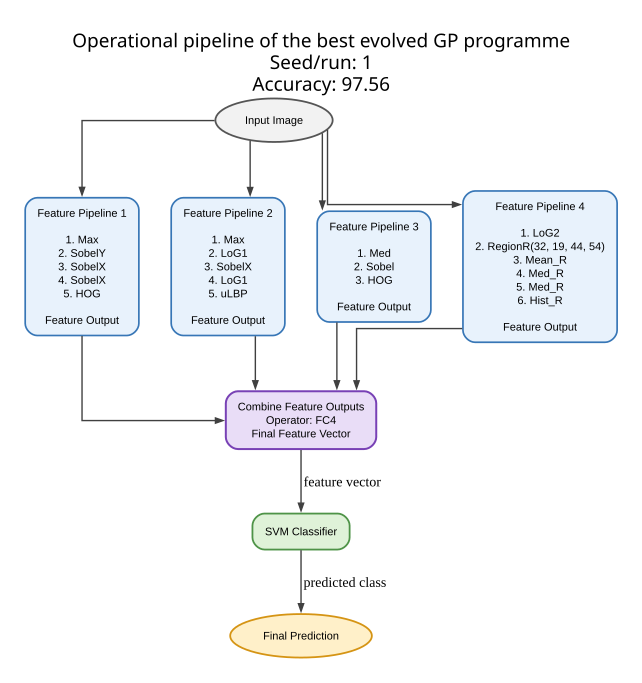

In [14]:
from pathlib import Path
import ast
from graphviz import Digraph
from IPython.display import display, SVG

PIPELINE_OUTPUT_DIRECTORY = Path("figures")
PIPELINE_OUTPUT_STEM = "best_original_gp_pipeline"

# Change this text if your classifier is not a linear SVM.
CLASSIFIER_LABEL = "SVM Classifier"

# Change this depending on the classification task.
PREDICTION_LABEL = "Final Prediction"

required_variables = [
    "program_tree",
    "best_program",
    "best_accuracy",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the original GP tree visualisation cell first.\n\n"
        "The following variables are currently missing:\n"
        + "\n".join(f"- {name}" for name in missing_variables)
    )


def pipeline_function_name(node):
    """
    Recover a readable function name from an AST function node.
    """

    if isinstance(node, ast.Name):
        return node.id

    if isinstance(node, ast.Attribute):
        parts = []
        current = node

        while isinstance(current, ast.Attribute):
            parts.append(current.attr)
            current = current.value

        if isinstance(current, ast.Name):
            parts.append(current.id)

        return ".".join(reversed(parts))

    return ast.unparse(node)


def pipeline_terminal_label(node):
    """
    Convert a non-function AST node into readable text.
    """

    if isinstance(node, ast.Name):
        return node.id

    if isinstance(node, ast.Constant):
        return repr(node.value)

    return ast.unparse(node)


def is_image_terminal(node):
    """
    Identify the terminal representing the original input image.
    """

    if not isinstance(node, ast.Name):
        return False

    return node.id.upper() in {
        "IMAGE",
        "IMG",
        "ARG0",
        "X",
        "INPUT",
        "INPUT_IMAGE",
    }


def is_concatenation_name(function_name):
    """
    Identify feature-combination primitives such as FC2, FC3 and FC4.
    """

    upper_name = function_name.upper()

    return (
        upper_name.startswith("FC")
        or "CONCAT" in upper_name
        or "COMBINE" in upper_name
    )


def extract_feature_branches(root_node):
    """
    Split the winning programme into top-level feature branches.

    Example:
        FC3(
            HOG(Sobel(Image)),
            Hist(Image),
            RIF(LoG(Image))
        )

    returns the three arguments of FC3 as separate feature branches.

    If the root is not a feature-combination primitive, the entire
    expression is treated as one branch.
    """

    if isinstance(root_node, ast.Call):
        root_name = pipeline_function_name(root_node.func)

        if is_concatenation_name(root_name):
            return root_node.args, root_name

    return [root_node], None


feature_branches, concatenation_operator = extract_feature_branches(
    program_tree
)


def format_operation(call_node):
    """
    Produce a readable label for one operation.

    Constants and named parameters are retained, while nested function
    calls are handled separately in dependency order.
    """

    operation_name = pipeline_function_name(call_node.func)

    parameter_labels = []

    for argument in call_node.args:
        if isinstance(argument, ast.Call):
            continue

        if is_image_terminal(argument):
            continue

        parameter_labels.append(
            pipeline_terminal_label(argument)
        )

    for keyword in call_node.keywords:
        keyword_name = (
            keyword.arg
            if keyword.arg is not None
            else "**kwargs"
        )

        parameter_value = pipeline_terminal_label(keyword.value)

        parameter_labels.append(
            f"{keyword_name}={parameter_value}"
        )

    if parameter_labels:
        return (
            f"{operation_name}"
            f"({', '.join(parameter_labels)})"
        )

    return operation_name


def extract_operations_in_dependency_order(node):
    """
    Extract operations in execution/dependency order.

    Inner operations appear before the outer operation.

    Example:
        HOG(Sobel(Gaussian(Image)))

    becomes:
        1. Gaussian
        2. Sobel
        3. HOG
    """

    operations = []

    def visit(current_node):
        if not isinstance(current_node, ast.Call):
            return

        # Visit nested operations first.
        for argument in current_node.args:
            if isinstance(argument, ast.Call):
                visit(argument)

        for keyword in current_node.keywords:
            if isinstance(keyword.value, ast.Call):
                visit(keyword.value)

        operations.append(
            format_operation(current_node)
        )

    visit(node)

    return operations


branch_operation_lists = [
    extract_operations_in_dependency_order(branch)
    for branch in feature_branches
]


print("CLIENT-FRIENDLY PIPELINE")
print("=" * 70)

if best_seed is not None:
    print(f"Winning seed/run: {best_seed}")

print(f"Test accuracy: {best_accuracy:.4f}")
print(f"Number of feature branches: {len(feature_branches)}")

if concatenation_operator is not None:
    print(f"Feature combination operator: {concatenation_operator}")

print()

for branch_number, operations in enumerate(
    branch_operation_lists,
    start=1,
):
    print(f"Feature branch {branch_number}")

    if operations:
        for operation_number, operation in enumerate(
            operations,
            start=1,
        ):
            print(f"  {operation_number}. {operation}")
    else:
        print("  Direct input feature")

    print()


PIPELINE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

pipeline_title_parts = [
    "Operational pipeline of the best evolved GP programme"
]

if best_seed is not None:
    pipeline_title_parts.append(
        f"Seed/run: {best_seed}"
    )

pipeline_title_parts.append(
    f"Accuracy: {best_accuracy:.2f}"
)

pipeline_title = r"\n".join(
    pipeline_title_parts
)

pipeline_graph = Digraph(
    name="Best_GP_Operational_Pipeline",
    format="svg",
)

pipeline_graph.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.35",
    nodesep="0.45",
    ranksep="0.65",
    splines="ortho",
    label=pipeline_title,
    labelloc="t",
    fontsize="19",
    fontname="Arial Bold",
)

pipeline_graph.attr(
    "node",
    fontname="Arial",
    fontsize="11",
    margin="0.18,0.12",
)

pipeline_graph.attr(
    "edge",
    color="#404040",
    penwidth="1.4",
    arrowsize="0.75",
)


pipeline_graph.node(
    "input_image",
    "Input Image",
    shape="ellipse",
    style="filled",
    fillcolor="#F2F2F2",
    color="#555555",
    penwidth="1.8",
)


branch_output_node_ids = []

for branch_number, operations in enumerate(
    branch_operation_lists,
    start=1,
):
    branch_node_id = f"feature_branch_{branch_number}"
    branch_output_node_ids.append(branch_node_id)

    if operations:
        operation_lines = [
            f"{number}. {operation}"
            for number, operation in enumerate(
                operations,
                start=1,
            )
        ]

        branch_label = (
            f"Feature Pipeline {branch_number}\n\n"
            + "\n".join(operation_lines)
            + "\n\nFeature Output"
        )

    else:
        branch_label = (
            f"Feature Pipeline {branch_number}\n\n"
            "Direct image-derived feature\n\n"
            "Feature Output"
        )

    pipeline_graph.node(
        branch_node_id,
        branch_label,
        shape="box",
        style="rounded,filled",
        fillcolor="#E8F2FC",
        color="#3776B6",
        penwidth="1.7",
    )

    pipeline_graph.edge(
        "input_image",
        branch_node_id,
    )


# Keep the feature branches on the same horizontal level.
if len(branch_output_node_ids) > 1:
    with pipeline_graph.subgraph() as same_rank:
        same_rank.attr(rank="same")

        for node_id in branch_output_node_ids:
            same_rank.node(node_id)


if concatenation_operator is not None:
    combination_label = (
        f"Combine Feature Outputs\n"
        f"Operator: {concatenation_operator}\n"
        f"Final Feature Vector"
    )
else:
    combination_label = (
        "Construct Final Feature Vector"
    )

pipeline_graph.node(
    "feature_vector",
    combination_label,
    shape="box",
    style="rounded,filled",
    fillcolor="#E9DDF7",
    color="#7841B5",
    penwidth="2.0",
)

for branch_node_id in branch_output_node_ids:
    pipeline_graph.edge(
        branch_node_id,
        "feature_vector",
    )


pipeline_graph.node(
    "classifier",
    CLASSIFIER_LABEL,
    shape="box",
    style="rounded,filled",
    fillcolor="#DFF2D8",
    color="#4E9347",
    penwidth="1.8",
)

pipeline_graph.node(
    "prediction",
    PREDICTION_LABEL,
    shape="ellipse",
    style="filled",
    fillcolor="#FFF0C9",
    color="#D59414",
    penwidth="1.8",
)

pipeline_graph.edge(
    "feature_vector",
    "classifier",
    label=" feature vector ",
)

pipeline_graph.edge(
    "classifier",
    "prediction",
    label=" predicted class ",
)


pipeline_base_path = (
    PIPELINE_OUTPUT_DIRECTORY
    / PIPELINE_OUTPUT_STEM
)

pipeline_saved_paths = {}

for output_format in ("svg", "png", "pdf"):
    pipeline_graph.format = output_format

    saved_path = pipeline_graph.render(
        filename=str(pipeline_base_path),
        cleanup=True,
    )

    pipeline_saved_paths[output_format] = Path(
        saved_path
    )


print("Saved pipeline diagrams")
print("-" * 70)

for output_format, saved_path in pipeline_saved_paths.items():
    print(
        f"{output_format.upper()}: "
        f"{saved_path.resolve()}"
    )


display(
    SVG(
        filename=str(
            pipeline_saved_paths["svg"]
        )
    )
)